<a href="https://colab.research.google.com/github/ekomissarov/demos/blob/main/alpha_selector_fws_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Alpha selector for A/B tests (v3)

Ноутбук помогает выбрать уровень значимости $\alpha$ из допустимой **False Win Share (FWS)**.

Ключевое различие:

$$
\alpha = P(\text{significant} \mid H_0)
\qquad\text{но}\qquad
FWS = P(H_0 \mid \text{significant win})
$$

Пусть $\pi_1$ — доля гипотез с реальным положительным эффектом, $\pi_0 = 1-\pi_1$, $a$ — вероятность ложной *победы* под $H_0$, $\text{power}$ — вероятность победы при реальном эффекте. Тогда

$$
FWS = \frac{a\,\pi_0}{a\,\pi_0 + \text{power}\cdot\pi_1}
\quad\Longleftrightarrow\quad
a = \frac{FWS\cdot \text{power}\cdot \pi_1}{(1-FWS)\cdot \pi_0}
$$

Здесь $a=\alpha$ для одностороннего теста и $a=\alpha/2$ для двустороннего (победой считается только значимый *положительный* эффект).

**Что нового по сравнению с v1**

1. **Две модели мощности.** *Mode A* — мощность фиксирована (замкнутая формула). *Mode B* — мощность зависит от $\alpha$, $n$, MDE и $\sigma$ (нормальное приближение). При фиксированном $n$ ужесточение $\alpha$ снижает мощность, и Mode B учитывает это; он внутренне согласован с заданными $n$ и размером эффекта (но см. ограничения внизу).
2. Явный выбор одностороннего / двустороннего теста.
3. Валидация входов, динамический sanity-check.
4. **Новый input layer (v3):** $\pi_1$ можно задать напрямую *или* вывести из исторического observed win rate (OWR). Важно: OWR $\neq \pi_1$, потому что победы включают и ложные срабатывания, и пропущенные эффекты.
5. **Тепловая карта** $\alpha^*$ как функции $\pi_1$ и целевого FWS.

Используйте результат как **инструмент поддержки решения**, а не как универсальное правило: он сильно зависит от допущения о доле реальных эффектов.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq
from IPython.display import Markdown, display

## Inputs

Все параметры ноутбука — в этой одной ячейке.

**Бизнес-допущения**
- `input_mode` — что вы знаете: `"true_effect_rate"` (оценка $\pi_1$ есть) или `"observed_win_rate"` (известна только историческая доля побед)
- `true_effect_rate` — доля экспериментов с реальным положительным эффектом ($\pi_1$); используется при `input_mode = "true_effect_rate"`
- `observed_win_rate`, `historical_alpha`, `historical_power` — историческая доля значимых положительных результатов и параметры решающего правила, при котором она наблюдалась; используются при `input_mode = "observed_win_rate"`
- `target_fws` — максимально допустимая доля ложных побед среди всех объявленных побед
- `two_sided` — `True`, если решение принимается по двустороннему тесту

**Mode A (фиксированная мощность)**
- `power_fixed` — целевая мощность, считается неизменной при любом $\alpha$

**Mode B (мощность зависит от дизайна эксперимента)**
- `n_per_arm` — размер выборки на группу
- `mde` — минимальный эффект, который хотим детектировать (в единицах метрики, абсолютный)
- `sigma` — стандартное отклонение метрики на пользователя (для конверсии $\sqrt{p(1-p)}$)

**Демо**
- `n_tests`, `alpha_demo` — для sanity-check

In [ ]:
# --- business assumptions ---
input_mode       = "true_effect_rate"   # or "observed_win_rate"
true_effect_rate = 0.20                 # used if input_mode == "true_effect_rate"
target_fws       = 0.05
two_sided        = True

# --- historical decision rule (used only if input_mode == "observed_win_rate") ---
observed_win_rate = 0.20   # share of past experiments with a significant POSITIVE result
historical_alpha  = 0.05   # full alpha used historically (two-sided if two_sided=True)
historical_power  = 0.80   # average power of past experiments for real effects

# --- Mode A: fixed power ---
power_fixed = 0.80

# --- Mode B: power from design (normal approximation, two-sample z-test of means) ---
n_per_arm = 14_000
mde       = 0.01      # absolute effect, e.g. +1 p.p. conversion
sigma     = 0.30      # e.g. baseline conversion 10% -> sqrt(0.1*0.9) = 0.30

# --- demo ---
n_tests    = 1000
alpha_demo = 0.05

## Model

- `a_win(alpha)` — вероятность ложной победы под $H_0$ (`alpha/2` для двустороннего теста).
- `power_from_design(...)` — $\text{power} = \Phi\!\left(\dfrac{MDE}{\sigma\sqrt{2/n}} - z_{1-a}\right)$.
- `fws_fn(...)` — FWS как функция $\alpha$.
- `alpha_fixed_power(...)` — замкнутое решение Mode A.
- `alpha_design_power(...)` — численное решение Mode B (корень монотонной функции, `brentq`).
- `n_required(...)` — сколько нужно на группу, чтобы получить заданную мощность при данном $\alpha$.
- `pi1_from_owr(...)` — оценка $\pi_1$ по историческому observed win rate.

In [ ]:
def _check_open_unit(name, x):
    if not (0 < x < 1):
        raise ValueError(f"{name} must be strictly between 0 and 1, got {x}")

def _check_positive(name, x):
    if not (x > 0):
        raise ValueError(f"{name} must be positive, got {x}")

def validate_inputs():
    if input_mode not in ("true_effect_rate", "observed_win_rate"):
        raise ValueError('input_mode must be "true_effect_rate" or "observed_win_rate"')
    if input_mode == "true_effect_rate":
        _check_open_unit("true_effect_rate", true_effect_rate)
    else:
        _check_open_unit("observed_win_rate", observed_win_rate)
        _check_open_unit("historical_alpha", historical_alpha)
        _check_open_unit("historical_power", historical_power)
    _check_open_unit("target_fws", target_fws)
    _check_open_unit("power_fixed", power_fixed)
    _check_open_unit("alpha_demo", alpha_demo)
    _check_positive("n_per_arm", n_per_arm)
    _check_positive("mde", mde)
    _check_positive("sigma", sigma)
    _check_positive("n_tests", n_tests)
    if not isinstance(two_sided, bool):
        raise TypeError("two_sided must be True or False")

validate_inputs()

def a_win(alpha, two_sided=two_sided):
    # false-win probability under H0
    return alpha / 2 if two_sided else alpha

def power_from_design(alpha, n=None, mde_=None, sigma_=None, two_sided=None):
    # power of a "win" (significant AND positive) for a two-sample z-test
    n      = n_per_arm if n is None else n
    mde_   = mde if mde_ is None else mde_
    sigma_ = sigma if sigma_ is None else sigma_
    ts     = globals()["two_sided"] if two_sided is None else two_sided
    se     = sigma_ * np.sqrt(2.0 / n)
    shift  = mde_ / se
    return norm.cdf(shift - norm.ppf(1 - a_win(alpha, ts)))

def fws_fn(alpha, pi1, power, two_sided=None):
    # False Win Share; power can be a scalar or an array aligned with alpha
    ts  = globals()["two_sided"] if two_sided is None else two_sided
    pi0 = 1 - pi1
    a   = a_win(alpha, ts)
    return a * pi0 / (a * pi0 + power * pi1)

def alpha_fixed_power(target_fws, pi1, power, two_sided=None):
    # Mode A: closed form. Returns alpha (capped at 1) and a flag if the cap was hit.
    ts  = globals()["two_sided"] if two_sided is None else two_sided
    pi0 = 1 - pi1
    a   = target_fws * power * pi1 / ((1 - target_fws) * pi0)
    alpha = a * (2 if ts else 1)
    return min(alpha, 1.0), alpha > 1.0

def alpha_design_power(target_fws, pi1, n=None, mde_=None, sigma_=None, two_sided=None):
    # Mode B: solve FWS(alpha; power(alpha)) = target by root finding.
    # FWS(alpha) increases from 0 (alpha -> 0) towards pi0 (alpha -> 1), so the root is unique.
    def g(alpha):
        p = power_from_design(alpha, n, mde_, sigma_, two_sided)
        return fws_fn(alpha, pi1, p, two_sided) - target_fws
    lo, hi = 1e-12, 1 - 1e-9
    if g(hi) < 0:           # target is looser than the worst possible FWS
        return hi, True
    return brentq(g, lo, hi, xtol=1e-14), False

def pi1_from_owr(owr, alpha_hist, power_hist, two_sided=None):
    # Observed win rate: OWR = a*(1 - pi1) + power*pi1  =>  pi1 = (OWR - a) / (power - a)
    ts = globals()["two_sided"] if two_sided is None else two_sided
    a  = a_win(alpha_hist, ts)
    if not (a < power_hist):
        raise ValueError("historical false-win rate must be below historical power")
    if owr <= a:
        raise ValueError(f"OWR={owr:.3f} <= false-win rate {a:.3f}: the data show no evidence of real effects (pi1 <= 0)")
    if owr >= power_hist:
        raise ValueError(f"OWR={owr:.3f} >= historical power {power_hist:.3f}: implies pi1 >= 1, check inputs")
    return (owr - a) / (power_hist - a)

def n_required(alpha, power, mde_=None, sigma_=None, two_sided=None):
    # per-arm sample size for the requested power at the given alpha
    mde_   = mde if mde_ is None else mde_
    sigma_ = sigma if sigma_ is None else sigma_
    ts     = globals()["two_sided"] if two_sided is None else two_sided
    z = norm.ppf(1 - a_win(alpha, ts)) + norm.ppf(power)
    return 2 * (sigma_ * z / mde_) ** 2

## Откуда берётся $\pi_1$

Если известна только историческая доля побед OWR, **нельзя** подставлять её как $\pi_1$: в неё входят ложные победы и не входят пропущенные эффекты. В простейшей модели

$$
OWR = a\,(1-\pi_1) + \text{power}\cdot\pi_1
\quad\Longrightarrow\quad
\pi_1 = \frac{OWR - a}{\text{power} - a},
$$

где $a$ — вероятность ложной победы при *историческом* $\alpha$ (то есть $\alpha/2$ для двустороннего теста).

Также следует помнить, что OWR привязан к решающему правилу, при котором он наблюдался. $\pi_1$ считается свойством пайплайна гипотез и переносится на новый $\alpha$, а OWR — нет: при другом $\alpha$ он станет другим. Оценка $\pi_1$ чувствительна к `historical_power`, которую обычно тоже приходится оценивать.

In [ ]:
if input_mode == "true_effect_rate":
    pi1 = true_effect_rate
    print(f"pi1 = {pi1:.3f} (задано напрямую)")
else:
    pi1 = pi1_from_owr(observed_win_rate, historical_alpha, historical_power)
    print(f"pi1 = {pi1:.3f}, выведено из OWR = {observed_win_rate:.1%} "
          f"(при historical alpha = {historical_alpha}, power = {historical_power:.0%})")
    print(f"Наивная подстановка pi1 = OWR дала бы {observed_win_rate:.3f} - "
          f"отличие на {observed_win_rate - pi1:+.3f}.")
    print(f"Для сравнения, FWS в прошлом был {a_win(historical_alpha) * (1 - pi1) / observed_win_rate:.1%}.")

pi1 = 0.200 (задано напрямую)


## Results

Сравниваем три сценария: стандартный $\alpha=0.05$, Mode A и Mode B.

- В Mode A мощность считается постоянной, поэтому рекомендованный $\alpha$ оптимистичен: на тех же $n$ и MDE при таком пороге мощность упадёт, а реальный FWS вырастет выше таргета.
- В Mode B мощность пересчитывается под каждый $\alpha$. Колонка `required n/arm (for target power)` показывает, сколько данных нужно, чтобы при данном $\alpha$ вернуть мощность `power_fixed`.

In [ ]:
alpha_A, capped_A = alpha_fixed_power(target_fws, pi1, power_fixed)
alpha_B, capped_B = alpha_design_power(target_fws, pi1)

def scenario(name, alpha, power):
    return {
        "scenario": name,
        "alpha": alpha,
        "power at this alpha": power,
        "FWS": fws_fn(alpha, pi1, power),
        "FWS with design power": fws_fn(alpha, pi1, power_from_design(alpha)),
        "required n/arm (for target power)": n_required(alpha, power_fixed),
    }

rows = [
    scenario("Conventional alpha=0.05 (power from design)", 0.05, power_from_design(0.05)),
    scenario("Mode A: fixed power",                          alpha_A, power_fixed),
    scenario("Mode B: power from n, MDE, sigma",             alpha_B, power_from_design(alpha_B)),
]
results = pd.DataFrame(rows)
results["alpha"] = results["alpha"].round(5)
results["power at this alpha"] = results["power at this alpha"].round(3)
results["FWS"] = results["FWS"].round(4)
results["FWS with design power"] = results["FWS with design power"].round(4)
results["required n/arm (for target power)"] = results["required n/arm (for target power)"].round(0).astype(int)

if capped_A or capped_B:
    print("WARNING: target FWS is so loose that alpha hit the cap of 1.0 - check your inputs.")
print(f"Test type: {'two-sided' if two_sided else 'one-sided'};  pi1 = {pi1:.2f};  target FWS = {target_fws:.1%}")
results

Test type: two-sided;  pi1 = 0.20;  target FWS = 5.0%


,scenario,alpha,power at this alpha,FWS,FWS with design power,required n/arm (for target power)
0,Conventional alpha=0.05 (power from design),0.05000,0.796,0.1116,0.1116,14128
1,Mode A: fixed power,0.02105,0.800,0.0500,0.0579,17845
2,"Mode B: power from n, MDE, sigma",0.01734,0.659,0.0500,0.0500,18675


## Interpretation

- **Mode A** отвечает на вопрос «какой $\alpha$ нужен, если мощность каким-то образом останется прежней». На текущем дизайне ($n$, MDE, $\sigma$) это оптимистично: при таком $\alpha$ мощность упадёт, а реальный FWS окажется **выше** таргета (см. колонку `FWS with design power`).
- **Mode B** отвечает на вопрос «какой $\alpha$ нужен при *текущем* дизайне». Из-за потери мощности порог получается ещё **строже**, чем в Mode A, а мощность при нём заметно ниже целевой — вы платите ошибками второго рода.
- Возможные способы выйти из этой вилки: увеличить выборку (колонка `required n/arm`), ослабить `target_fws` или увеличить $\pi_1$ за счёт более качественного отбора гипотез.

## FWS как функция $\alpha$

Сплошная линия — Mode A (мощность фиксирована), штрих-пунктир — Mode B (мощность зависит от $\alpha$). Точки — найденные рекомендации.

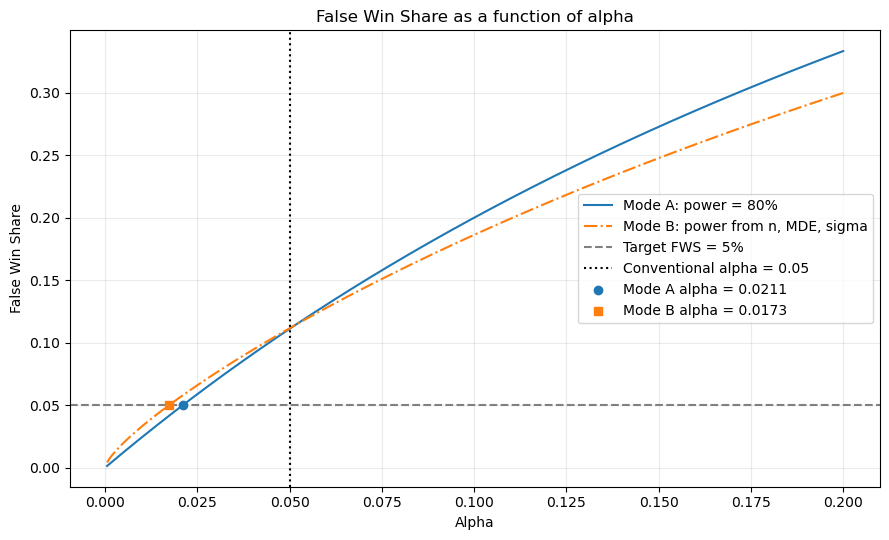

In [ ]:
alpha_max = min(1.0, max(0.20, 1.5 * max(alpha_A, alpha_B)))
alphas = np.linspace(0.0005, alpha_max, 400)

fws_A = fws_fn(alphas, pi1, power_fixed)
fws_B = fws_fn(alphas, pi1, power_from_design(alphas))

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(alphas, fws_A, label=f"Mode A: power = {power_fixed:.0%}")
ax.plot(alphas, fws_B, linestyle="-.", label="Mode B: power from n, MDE, sigma")
ax.axhline(target_fws, linestyle="--", color="gray", label=f"Target FWS = {target_fws:.0%}")
ax.axvline(0.05, linestyle=":", color="black", label="Conventional alpha = 0.05")
ax.scatter([alpha_A], [target_fws], zorder=5, label=f"Mode A alpha = {alpha_A:.4f}")
ax.scatter([alpha_B], [target_fws], zorder=5, marker="s", label=f"Mode B alpha = {alpha_B:.4f}")
ax.set_xlabel("Alpha")
ax.set_ylabel("False Win Share")
ax.set_title("False Win Share as a function of alpha")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## Sanity check: почему $\alpha = 0.05$ всё ещё может давать много ложных побед

Текст ниже генерируется из параметров: при смене входов он обновится.

In [ ]:
def demo_table(alpha, power):
    true_h = n_tests * pi1
    null_h = n_tests - true_h
    true_w = true_h * power
    false_w = null_h * a_win(alpha)
    obs = true_w + false_w
    return {
        "Tests with real effect": true_h,
        "Tests with no effect": null_h,
        "True wins": true_w,
        "False wins": false_w,
        "Observed wins": obs,
        "False Win Share": false_w / obs,
    }

power_demo_B = float(power_from_design(alpha_demo))
demo = pd.DataFrame({
    f"Mode A (power={power_fixed:.0%})": demo_table(alpha_demo, power_fixed),
    f"Mode B (power={power_demo_B:.1%})": demo_table(alpha_demo, power_demo_B),
}).round(3)

dA = demo_table(alpha_demo, power_fixed)
test_word = "двусторонний" if two_sided else "односторонний"
display(Markdown(
    f"Допущения: {pi1:.0%} гипотез имеют реальный эффект, мощность {power_fixed:.0%}, "
    f"alpha = {alpha_demo:.0%} ({test_word} тест, ложная победа с вероятностью {a_win(alpha_demo):.1%}).\n\n"
    f"Из {n_tests:,} экспериментов: **{dA['Tests with real effect']:.0f}** с реальным эффектом "
    f"-> около **{dA['True wins']:.0f}** настоящих побед; **{dA['Tests with no effect']:.0f}** без эффекта "
    f"-> около **{dA['False wins']:.0f}** ложных побед.\n\n"
    f"Итого FWS = {dA['False wins']:.0f} / ({dA['True wins']:.0f} + {dA['False wins']:.0f}) = "
    f"**{dA['False Win Share']:.1%}**, то есть не {alpha_demo:.0%}."
))
demo

Допущения: 20% гипотез имеют реальный эффект, мощность 80%, alpha = 5% (двусторонний тест, ложная победа с вероятностью 2.5%).

Из 1,000 экспериментов: **200** с реальным эффектом -> около **160** настоящих побед; **800** без эффекта -> около **20** ложных побед.

Итого FWS = 20 / (160 + 20) = **11.1%**, то есть не 5%.

,Mode A (power=80%),Mode B (power=79.6%)
Tests with real effect,200.000,200.000
Tests with no effect,800.000,800.000
True wins,160.000,159.284
False wins,20.000,20.000
Observed wins,180.000,179.284
False Win Share,0.111,0.112


## Sensitivity: зависимость FWS от доли реальных эффектов

Сплошные линии — Mode A, пунктир — Mode B. При низкой доле реальных эффектов даже $\alpha=0.05$ даёт высокий FWS.

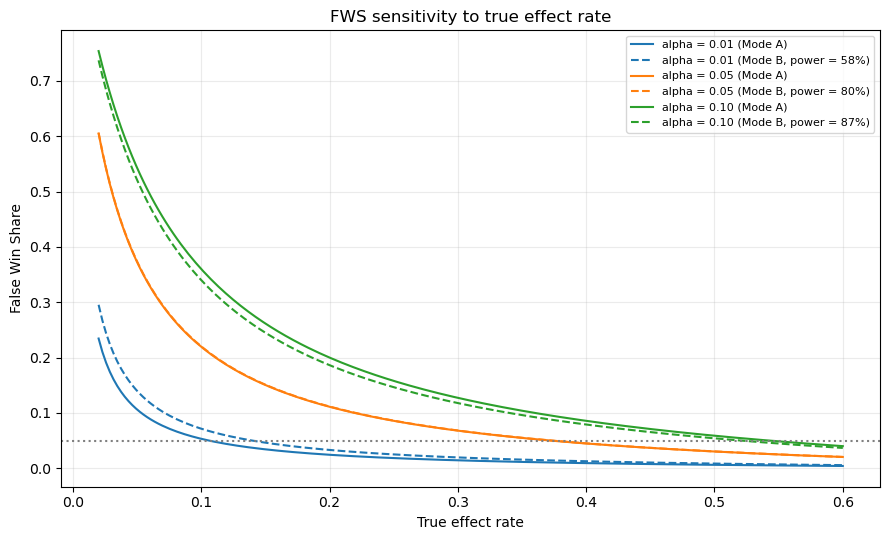

In [ ]:
effect_rates = np.linspace(0.02, 0.60, 200)
fig, ax = plt.subplots(figsize=(9, 5.5))
for i, a in enumerate([0.01, 0.05, 0.10]):
    color = f"C{i}"
    ax.plot(effect_rates, fws_fn(a, effect_rates, power_fixed), color=color,
            label=f"alpha = {a:.2f} (Mode A)")
    ax.plot(effect_rates, fws_fn(a, effect_rates, power_from_design(a)), color=color,
            linestyle="--", label=f"alpha = {a:.2f} (Mode B, power = {float(power_from_design(a)):.0%})")
ax.axhline(target_fws, linestyle=":", color="gray")
ax.set_xlabel("True effect rate")
ax.set_ylabel("False Win Share")
ax.set_title("FWS sensitivity to true effect rate")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## Sensitivity: как рекомендованный $\alpha$ зависит от размера выборки

Чем больше выборка, тем выше мощность при любом $\alpha$, поэтому при том же `target_fws` можно позволить **менее строгий** порог (больший $\alpha$). Рост ограничен: при мощности $\to 1$ рекомендованный $\alpha$ выходит на плато $\dfrac{FWS\cdot\pi_1}{(1-FWS)\,\pi_0}$ (удвоенное для двустороннего теста). При малых $n$ мощность низкая, и для удержания FWS нужен очень строгий $\alpha$. Серая пунктирная линия — Mode A (мощность считается постоянной), точечная — предел при бесконечной выборке.

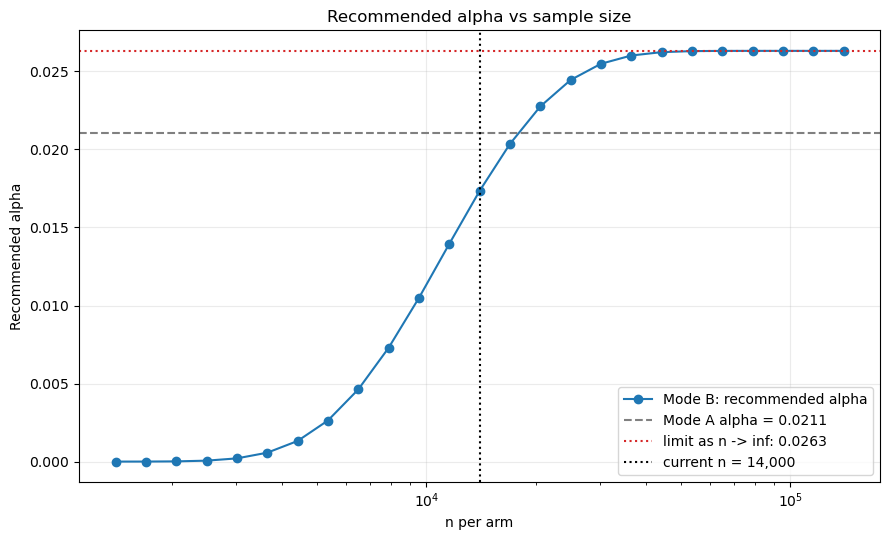

In [ ]:
ns = np.unique(np.geomspace(max(100, n_per_arm / 10), n_per_arm * 10, 25).astype(int))
alpha_by_n = [alpha_design_power(target_fws, pi1, n=n)[0] for n in ns]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(ns, alpha_by_n, marker="o", label="Mode B: recommended alpha")
ax.axhline(alpha_A, linestyle="--", color="gray", label=f"Mode A alpha = {alpha_A:.4f}")
alpha_limit = min(1.0, (2 if two_sided else 1) * target_fws * pi1 / ((1 - target_fws) * (1 - pi1)))
ax.axhline(alpha_limit, linestyle=":", color="C3", label=f"limit as n -> inf: {alpha_limit:.4f}")
ax.axvline(n_per_arm, linestyle=":", color="black", label=f"current n = {n_per_arm:,}")
ax.set_xscale("log")
ax.set_xlabel("n per arm")
ax.set_ylabel("Recommended alpha")
ax.set_title("Recommended alpha vs sample size")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## Карта решений: $\alpha^*$ как функция $\pi_1$ и целевого FWS

Mode A, при `power_fixed`. Для каждой комбинации «доля реальных эффектов — допустимая доля ложных побед» видно, какой $\alpha$ нужен. Звёздочка — ваши текущие параметры.

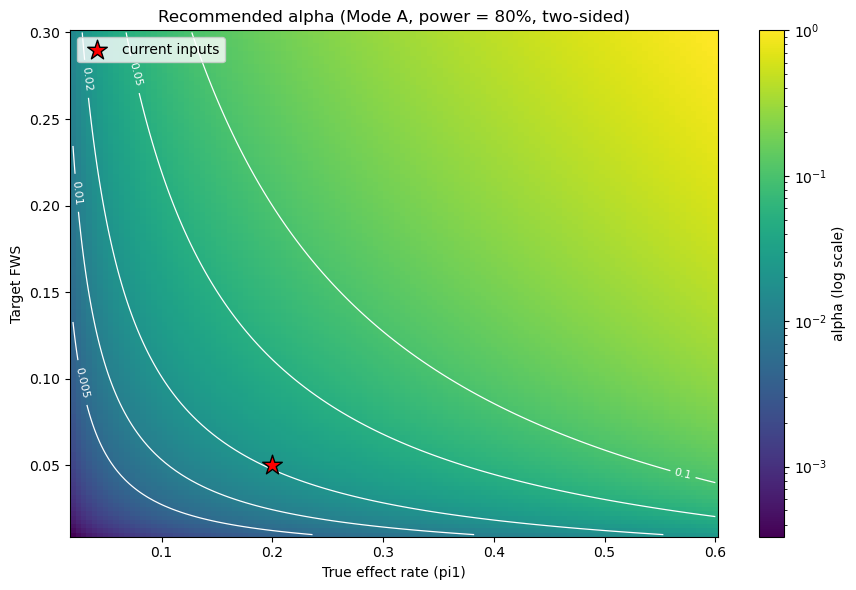

In [ ]:
pi_grid  = np.linspace(0.02, 0.60, 120)
fws_grid = np.linspace(0.01, 0.30, 120)
PI, FW = np.meshgrid(pi_grid, fws_grid)
ALPHA = np.minimum(1.0, (2 if two_sided else 1) * FW * power_fixed * PI / ((1 - FW) * (1 - PI)))

from matplotlib.colors import LogNorm
fig, ax = plt.subplots(figsize=(9, 6))
mesh = ax.pcolormesh(PI, FW, ALPHA, shading="auto", norm=LogNorm(vmin=max(ALPHA.min(), 1e-4), vmax=ALPHA.max()))
cs = ax.contour(PI, FW, ALPHA, levels=[0.005, 0.01, 0.02, 0.05, 0.10], colors="white", linewidths=0.9)
ax.clabel(cs, fmt="%.3g", fontsize=8)
ax.scatter([pi1], [target_fws], marker="*", s=220, color="red", edgecolor="black", zorder=5, label="current inputs")
ax.set_xlabel("True effect rate (pi1)")
ax.set_ylabel("Target FWS")
ax.set_title(f"Recommended alpha (Mode A, power = {power_fixed:.0%}, {'two' if two_sided else 'one'}-sided)")
fig.colorbar(mesh, ax=ax, label="alpha (log scale)")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

## Practical note

Доля реальных эффектов $\pi_1$ напрямую не наблюдается; её нужно осторожно оценивать по историческим данным экспериментов (например, через распределение p-value или эмпирический Байес).

Ограничения модели:

- **Двухкомпонентная модель состояния мира.** Все гипотезы без положительного эффекта трактуются как $H_0$ (нулевой эффект). Реальные отрицательные эффекты отдельно не моделируются. Для них вероятность ложной положительной победы $\Phi(\delta/SE - z_{1-a}) < a$, то есть ниже номинальной, поэтому $a$ — верхняя граница (наихудший случай составной $H_0$), и реальный FWS при наличии отрицательных эффектов не выше расчётного. Результат в этом направлении консервативен. Напротив, положительные эффекты меньше MDE в модели не учитываются: их фактическая мощность ниже принятой.
- **Двухточечная модель эффектов.** Предполагается, что эффект либо нулевой, либо ровно равен MDE. В реальности эффекты распределены непрерывно, и в знаменателе FWS должна стоять мощность, усреднённая по распределению эффектов: $E_\delta[\text{Power}(\delta, \alpha)]$. Это следующий уровень модели.
- **Происхождение $\pi_1$ — главный риск.** Нельзя подставлять историческую долю значимых результатов как долю реальных эффектов. Используйте режим `observed_win_rate` или более аккуратные оценки (эмпирический Байес по распределению p-value). Неверно заданный $\pi_1$ даст внешне точный, но неверный результат.
- **Нормальное приближение** для разности средних с известной $\sigma$ и равными группами. Для сильно скошенных метрик, малых выборок и ratio-метрик нужны симуляции или дельта-метод.
- **Победа = значимый положительный эффект.** Значимые отрицательные результаты в FWS не входят.

Дополнительно учитывайте:

- стоимость ложноположительных и ложноотрицательных решений;
- длительность эксперимента;
- sequential testing / peeking;
- множественные сравнения;
- гетерогенные эффекты;
- политику раскатки и guardrail-метрики.

Результат лучше трактовать как **порог принятия решения при явных допущениях**, а не как универсально «правильный alpha».